In [ ]:
# Copyright 2026 International Business Machines

# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at

#     http://www.apache.org/licenses/LICENSE-2.0

# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# 1.2 Multi-Class Segmentation Inference

## Zonal Saltmarsh Classification with TerraMind

---

## 📚 Workshop Overview

In this notebook, you will apply your learning from notebook 1.1 to run inference for a **multi-class segmentation task** to predict specific saltmarsh zones.

Building on the binary classification approach (Not Saltmarsh vs Saltmarsh), you will now work with a more complex model that distinguishes between different ecological zones within saltmarsh environments.

You will:
- Download a pre-trained multi-class zonal classification model from HuggingFace
- Run inference on RGB+DEM imagery
- Visualize predictions for 4 distinct saltmarsh zones
- Compare predictions against ground truth labels

---

## 🎯 Saltmarsh Zones

The model classifies pixels into **4 distinct classes**:

1. **Class 0: Not Saltmarsh** - Areas outside saltmarsh habitat
2. **Class 1: Pioneer/Spartina** - Early colonization zone dominated by Spartina species
3. **Class 2: Mid-Low Marsh** - Intermediate elevation zone with diverse vegetation
4. **Class 3: Upper Marsh** - High elevation zone with terrestrial transition species

These zones are strongly correlated with elevation, making the Digital Elevation Model (DEM) a critical input for accurate classification.

---

## 📋 Prerequisites

Please read the [instructions](https://github.com/IBM/ML4EO-workshop-2026) on the repository landing page.

---

## 0. Setup

### 0.1 Check Python Version

It's recommended that you run this notebook using Python 3.12.

In [1]:
!python --version

Python 3.12.10


### 0.2 Install and Import Dependencies

If running locally, ensure you have the necessary packages installed. This assumes you're in the project root directory.

Once installed, import dependencies.

In [ ]:
# Install dependencies
import sys
if 'google.colab' in sys.modules:
  !uv pip install --system gdown
else:
  !pip install uv
  !uv pip install gdown

In [2]:
import os
import warnings
from pathlib import Path
from huggingface_hub import hf_hub_download

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

print("✓ Dependencies imported successfully!")

✓ Dependencies imported successfully!


### 0.3 Download Inference Dataset

Download the inference dataset from Google Drive. This contains RGB imagery, DEM data, and multi-class labels for saltmarsh zones.

Expected structure after extraction:
```
data/inference/
  ├── images/
  │   ├── aerial/     # RGB imagery (2m resolution)
  │   └── dem/        # Digital Elevation Model (10m resolution)
  ├── labels/
  │   └── rgb_dem_zones/  # Multi-class labels (4 classes)
  └── pred/
      └── rgb_dem_zones/  # Predictions will be saved here
```

In [ ]:
import gdown
import zipfile

# TODO: Replace with actual Google Drive file ID for multi-class inference data
inference_file_id = "YOUR_INFERENCE_DATA_FILE_ID_HERE"

# Download location
inference_zip_output = "inference_multiclass_data.zip"
inference_extract_to = "../../data"

# Download the zip file from Google Drive
if not os.path.isfile(inference_zip_output):
    print("Downloading inference data from Google Drive...")
    gdown.download(
        f"https://drive.google.com/uc?id={inference_file_id}",
        inference_zip_output,
        quiet=False
    )
    print(f"✓ Downloaded to {inference_zip_output}")
else:
    print(f"✓ Zip file already exists: {inference_zip_output}")

# Extract the zip file
if os.path.isfile(inference_zip_output):
    print(f"\nExtracting to {inference_extract_to}...")
    with zipfile.ZipFile(inference_zip_output, 'r') as zip_ref:
        zip_ref.extractall(inference_extract_to)
    print("✓ Extraction complete!")
    
    # Verify the structure
    inference_data_path = Path(inference_extract_to) / "inference"
    if inference_data_path.exists():
        print(f"\n✓ Inference data ready at: {inference_data_path}")
    else:
        print(f"⚠ Warning: Expected directory not found: {inference_data_path}")
else:
    print("⚠ Download failed. Please check the file_id and try again.")

### 0.4 Set Up Paths

Define paths for inference data and outputs.

In [3]:
# Project root (adjust if running from different location)
project_root = Path("../..").resolve()
print(f"Project root: {project_root}")

# Base filename for the dataset (UPDATE THIS for different datasets)
BASE_FILENAME = "ortho_RGBN_dee_2024"  # UPDATE THIS for different datasets

# Base inference directory
inference_base = project_root / "data/inference"

# Inference data paths
inference_images_aerial = inference_base / "images/aerial"
inference_images_dem = inference_base / "images/dem"

# Label and prediction paths for multi-class zones
inference_labels_zones = inference_base / "labels/rgb_dem_zone"
zones_inference_output = inference_base / "pred/rgb_dem_zone"

# Create output directory
os.makedirs(zones_inference_output, exist_ok=True)

# Hardcoded file paths (2m resolution for RGB+DEM)
# RGB+DEM Model files (2m resolution)
zones_img_file = inference_images_aerial / f"{BASE_FILENAME}_res_2m_cleaned_img.tif"
zones_dem_file = inference_images_dem / f"{BASE_FILENAME}_res_10m_cleaned_img_dtm.tif"
zones_lab_file = inference_labels_zones / f"{BASE_FILENAME}_res_2m_cleaned_lab.tif"
zones_pred_file = zones_inference_output / f"{BASE_FILENAME}_res_2m_cleaned_img_pred.tif"

print(f"\n✓ Paths configured for multi-class inference:")
print(f"  RGB image: {zones_img_file}")
print(f"  DEM: {zones_dem_file}")
print(f"  Labels: {zones_lab_file}")
print(f"  Predictions output: {zones_pred_file}")

Project root: /Users/annejones/old-macbook/ibm-repos/ML4EO-workshop-2026

✓ Paths configured for multi-class inference:
  RGB image: /Users/annejones/old-macbook/ibm-repos/ML4EO-workshop-2026/data/inference/images/aerial/ortho_RGBN_dee_2024_res_2m_cleaned_img.tif
  DEM: /Users/annejones/old-macbook/ibm-repos/ML4EO-workshop-2026/data/inference/images/dem/ortho_RGBN_dee_2024_res_10m_cleaned_img_dtm.tif
  Labels: /Users/annejones/old-macbook/ibm-repos/ML4EO-workshop-2026/data/inference/labels/rgb_dem_zone/ortho_RGBN_dee_2024_res_2m_cleaned_lab.tif
  Predictions output: /Users/annejones/old-macbook/ibm-repos/ML4EO-workshop-2026/data/inference/pred/rgb_dem_zone/ortho_RGBN_dee_2024_res_2m_cleaned_img_pred.tif


---

## 1. Download Pre-Trained Multi-Class Model

### 1.1 Download from HuggingFace

We'll download the pre-trained multi-class zonal classification model from HuggingFace. This model is trained to distinguish between 4 saltmarsh zones using RGB+DEM data.

In [4]:
# Import helper function for downloading from HuggingFace
from helper import download_model_from_hf

# HuggingFace repository information for multi-class zonal model
zones_repo_id = "rosielickorish/ibm-geospatial-saltmarsh-uk-rgbdem-zone-2m"
zones_config_name = "config-ibm-geospatial-saltmarsh-uk-rgbdem-zone-2m.yaml"
zones_checkpoint_name = "ibm-geospatial-saltmarsh-uk-rgbdem-zone-2m_state_dict.ckpt"

print("Downloading multi-class zonal model from HuggingFace...")
zones_config_path, zones_checkpoint_path = download_model_from_hf(
    repo_id=zones_repo_id,
    config_name=zones_config_name,
    checkpoint_name=zones_checkpoint_name,
    project_root=project_root
)
print(f"✓ Config: {zones_config_path}")
print(f"✓ Checkpoint: {zones_checkpoint_path}")

print("\n✓ Multi-class model downloaded successfully!")

(…)spatial-saltmarsh-uk-rgbdem-zone-2m.yaml:   0%|          | 0.00/2.73k [00:00<?, ?B/s]

✓ Config downloaded

⏳ This may take a few minutes (~350MB file)...


ibm-geospatial-saltmarsh-uk-rgbdem-zone-(…):   0%|          | 0.00/362M [00:00<?, ?B/s]

✓ Checkpoint downloaded
✓ Config: /Users/annejones/old-macbook/ibm-repos/ML4EO-workshop-2026/configs/inference/config-ibm-geospatial-saltmarsh-uk-rgbdem-zone-2m.yaml
✓ Checkpoint: /Users/annejones/old-macbook/ibm-repos/ML4EO-workshop-2026/data/checkpoints/ibm-geospatial-saltmarsh-uk-rgbdem-zone-2m_state_dict.ckpt

✓ Multi-class model downloaded successfully!


---

## 2. Run Inference

### 2.1 Prepare Inference Command

Construct the prediction command using the downloaded config and checkpoint.

In [ ]:
# Output directory for this run
output_dir = project_root / "data/inference_runs/multiclass"
os.makedirs(output_dir, exist_ok=True)

# Construct the prediction command for multi-class zonal model
zones_predict_command = f"""terratorch predict \
    --config {zones_config_path} \
    --ckpt_path {zones_checkpoint_path} \
    --trainer.default_root_dir {output_dir} \
    --predict_output_dir {zones_inference_output} \
    --data.init_args.predict_data_root.RGB {inference_images_aerial} \
    --data.init_args.predict_data_root.DEM {inference_images_dem}"""

print("Multi-class Zonal Prediction command:")
print(zones_predict_command)
print(f"\nUsing config: {zones_config_path}")
print(f"Using checkpoint: {zones_checkpoint_path}")

### 2.2 Execute Inference

Run the prediction command to generate multi-class segmentation predictions.

In [ ]:
# Run multi-class zonal prediction
!{zones_predict_command}

---

## 3. Visualize Results

### 3.1 Load Visualization Functions

Import helper functions for loading and visualizing the results.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Import visualization helper functions
from helper import load_raster, normalize_rgb, plot_panel, get_multiclass_colormap

print("✓ Visualization functions loaded from helper.py")

✓ Visualization functions loaded from helper.py


### 3.2 Load and Display Multi-Class Results

Load the RGB imagery, DEM, labels, and predictions for visualization.

In [9]:
# Load RGB image (extract first 3 bands for RGB)
rgb_data = load_raster(zones_img_file, rgb_only=True)
rgb_normalized = normalize_rgb(rgb_data)

# Load DEM
dem_data = load_raster(zones_dem_file)

# Load labels and predictions
labels_data = load_raster(zones_lab_file)
predictions_data = load_raster(zones_pred_file)

print("✓ Data loaded successfully")
print(f"  RGB shape: {rgb_normalized.shape if rgb_normalized is not None else 'None'}")
print(f"  DEM shape: {dem_data.shape if dem_data is not None else 'None'}")
print(f"  Labels shape: {labels_data.shape if labels_data is not None else 'None'}")
print(f"  Predictions shape: {predictions_data.shape if predictions_data is not None else 'None'}")

✓ Data loaded successfully
  RGB shape: (6000, 4000, 3)
  DEM shape: (1200, 800)
  Labels shape: (6000, 4000)
  Predictions shape: (6000, 4000)


### 3.3 Visualize Multi-Class Predictions

Create a visualization showing:
- RGB input imagery
- DEM (elevation data)
- Ground truth labels (4 classes)
- Model predictions (4 classes)

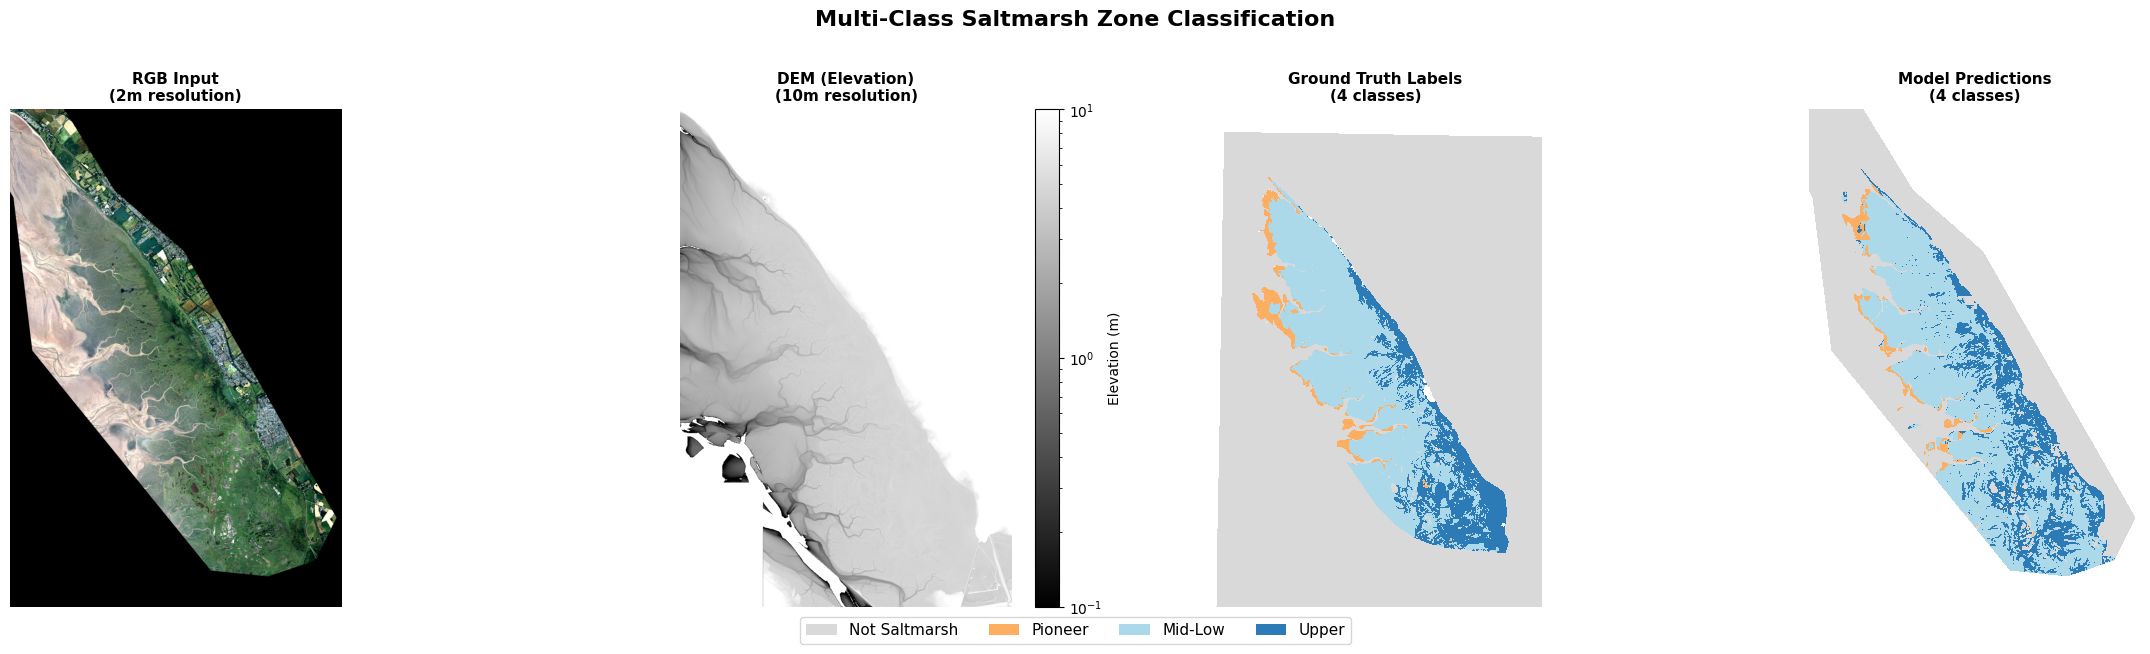


✓ Visualization complete!

Class Distribution in Labels:
  Not Saltmarsh: 17,003,750 pixels (70.85%)
  Pioneer: 330,625 pixels (1.38%)
  Mid-Low: 3,479,525 pixels (14.50%)
  Upper: 1,235,250 pixels (5.15%)

Class Distribution in Predictions:
  Not Saltmarsh: 4,827,376 pixels (20.11%)
  Pioneer: 221,119 pixels (0.92%)
  Mid-Low: 3,901,616 pixels (16.26%)
  Upper: 1,466,181 pixels (6.11%)


In [10]:
# Get multi-class colormap and labels
class_cmap, class_labels, class_colors = get_multiclass_colormap()

# Create figure with 1 row and 4 columns
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle('Multi-Class Saltmarsh Zone Classification', fontsize=16, fontweight='bold', y=1.02)

# Plot RGB input
plot_panel(axes[0], rgb_normalized, 'RGB Input\n(2m resolution)', cmap=None)

# Plot DEM with log scale
plot_panel(axes[1], dem_data, 'DEM (Elevation)\n(10m resolution)', is_dem=True)

# Plot ground truth labels (4 classes)
plot_panel(axes[2], labels_data, 'Ground Truth Labels\n(4 classes)', 
          cmap=class_cmap, is_categorical=True, n_classes=4)

# Plot predictions (4 classes)
plot_panel(axes[3], predictions_data, 'Model Predictions\n(4 classes)', 
          cmap=class_cmap, is_categorical=True, n_classes=4)

# Add legend for classes
legend_elements = [Patch(facecolor=class_colors[i], label=class_labels[i]) 
                  for i in range(4)]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, 
          bbox_to_anchor=(0.5, -0.05), fontsize=11, frameon=True)

plt.tight_layout()
plt.show()

print("\n✓ Visualization complete!")
print("\nClass Distribution in Labels:")
if labels_data is not None:
    for i in range(4):
        count = np.sum(labels_data == i)
        percentage = (count / labels_data.size) * 100
        print(f"  {class_labels[i]}: {count:,} pixels ({percentage:.2f}%)")

print("\nClass Distribution in Predictions:")
if predictions_data is not None:
    for i in range(4):
        count = np.sum(predictions_data == i)
        percentage = (count / predictions_data.size) * 100
        print(f"  {class_labels[i]}: {count:,} pixels ({percentage:.2f}%)")

---

## 4. Next Steps

Congratulations! You've successfully run multi-class inference for saltmarsh zone classification.

### Key Takeaways:

- **Multi-class segmentation** provides more detailed ecological information than binary classification
- **Elevation data (DEM)** is critical for distinguishing between saltmarsh zones
- **Zone classification** helps understand saltmarsh structure and ecological function

### Continue Learning:

- **Notebook 2.1: TerraKit Data Prep** - Learn how to prepare your own training data
- **Notebook 2.2: Performance Optimization** - Improve model accuracy through iteration

### Resources:

- [TerraTorch Documentation](https://github.com/IBM/terratorch)
- [TerraMind Models on HuggingFace](https://huggingface.co/ibm-esa-geospatial)
- [Workshop Repository](https://github.com/IBM/ML4EO-workshop-2026)

---